In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ast

In [2]:
# Data Sources
data_albums = pd.read_csv("../data/spotify_albums.csv")
data_artists = pd.read_csv("../data/spotify_artists.csv")
data_tracks = pd.read_csv("../data/spotify_tracks.csv")

# Features Extracted
data_audio = pd.read_csv("../data/low_level_audio_features.csv")
data_lyrics = pd.read_csv("../data/lyrics_features.csv")

In [3]:
# show the number of observations and features,
# names of the features,
# and the first 5 rows for each dataset

for name, df in {
    "albums": data_albums,
    "artists": data_artists,
    "tracks": data_tracks,
    "audio": data_audio,
    "lyrics": data_lyrics,
}.items():
    print(f"\n{name.upper()}")
    print(f"Observations: {len(df)}, Features: {len(df.columns)}")
    print(df.columns.tolist())
    display(df.head(5))


ALBUMS
Observations: 75511, Features: 16
['Unnamed: 0', 'album_type', 'artist_id', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'total_tracks', 'track_id', 'track_name_prev', 'uri', 'type']


,Unnamed: 0,album_type,artist_id,available_markets,external_urls,href,id,images,name,release_date,release_date_precision,total_tracks,track_id,track_name_prev,uri,type
0,0,single,3DiDSECUqqY1AuBP8qtaIa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1g...,https://api.spotify.com/v1/albums/1gAM7M4rBwEb...,1gAM7M4rBwEbSPeAQR2nx1,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",If I Ain't Got You EP,2019-02-08,day,6,2iejTMy9XZ8Gaae0aQ2yl0,track_32,spotify:album:1gAM7M4rBwEbSPeAQR2nx1,album
1,1,album,6s1pCNXcbdtQJlsnM1hRIA,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/4K...,https://api.spotify.com/v1/albums/4KfJZV7WfolY...,4KfJZV7WfolYlxBzOTo66s,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Shostakovich Symphony No.5 - Four Romances on ...,2019-03-01,day,8,1WQfghEjszJJ4H8MAWrQ2C,track_11,spotify:album:4KfJZV7WfolYlxBzOTo66s,album
2,2,single,5YjfNaHq05WrwldRe1QSBc,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/7n...,https://api.spotify.com/v1/albums/7nLYY7uAVUb5...,7nLYY7uAVUb57kpd7tZxnS,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Take My Bass,2019-03-14,day,1,3jJKj4QTK3v18ZSwpk7AcV,track_15,spotify:album:7nLYY7uAVUb57kpd7tZxnS,album
3,3,single,2G9Vc16JCpnZmK4uGH46Fa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/6p...,https://api.spotify.com/v1/albums/6p20Rt4x2Qn5...,6p20Rt4x2Qn5mUMRi1s6pj,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Hypnotizing (Are U),2016-11-16,day,1,1xGtDafUZbHyYC3Xarcbrj,track_46,spotify:album:6p20Rt4x2Qn5mUMRi1s6pj,album
4,4,single,2dwM9OcE4c3Ph1UBINSodx,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1X...,https://api.spotify.com/v1/albums/1XeoOqC1q7U2...,1XeoOqC1q7U2iyLEQJ64cu,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Sunshine,2018-07-20,day,1,0gWtsXvXOzAT6FtM3ur8in,track_10,spotify:album:1XeoOqC1q7U2iyLEQJ64cu,album



ARTISTS
Observations: 56129, Features: 9
['Unnamed: 0', 'artist_popularity', 'followers', 'genres', 'id', 'name', 'track_id', 'track_name_prev', 'type']


,Unnamed: 0,artist_popularity,followers,genres,id,name,track_id,track_name_prev,type
0,0,44,23230,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",4mGnpjhqgx4RUdsIJiURdo,Juliano Cezar,0wmDmAILuW9e2aRttkl4aC,track_9,artist
1,1,22,313,[],1dLnVku4VQUOLswwDFvRc9,The Grenadines,4wqwj0gA8qPZKLl5WVqXml,track_30,artist
2,2,26,1596,['danish pop rock'],6YVY310fjfUzKi8hiqR7iK,Gangway,1bFqWDbvHmZe2f4Nf9qaD8,track_38,artist
3,3,31,149,['uk alternative pop'],2VElyouiCfoYPDJluzwJwK,FADES,3MFSUBAidPzRBbIS7BDj1S,track_34,artist
4,4,21,11,['french baroque'],4agVy03qW8juSysCTUOuDI,Jean-Pierre Guignon,2r3q57FhxdsCyYr0kuDq4b,track_26,artist



TRACKS
Observations: 101939, Features: 32
['Unnamed: 0', 'acousticness', 'album_id', 'analysis_url', 'artists_id', 'available_markets', 'country', 'danceability', 'disc_number', 'duration_ms', 'energy', 'href', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'lyrics', 'mode', 'name', 'playlist', 'popularity', 'preview_url', 'speechiness', 'tempo', 'time_signature', 'track_href', 'track_name_prev', 'track_number', 'uri', 'valence', 'type']


,Unnamed: 0,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track



AUDIO
Observations: 101909, Features: 209
['Unnamed: 0', 'Chroma_1', 'Chroma_10', 'Chroma_11', 'Chroma_12', 'Chroma_2', 'Chroma_3', 'Chroma_4', 'Chroma_5', 'Chroma_6', 'Chroma_7', 'Chroma_8', 'Chroma_9', 'MEL_1', 'MEL_10', 'MEL_100', 'MEL_101', 'MEL_102', 'MEL_103', 'MEL_104', 'MEL_105', 'MEL_106', 'MEL_107', 'MEL_108', 'MEL_109', 'MEL_11', 'MEL_110', 'MEL_111', 'MEL_112', 'MEL_113', 'MEL_114', 'MEL_115', 'MEL_116', 'MEL_117', 'MEL_118', 'MEL_119', 'MEL_12', 'MEL_120', 'MEL_121', 'MEL_122', 'MEL_123', 'MEL_124', 'MEL_125', 'MEL_126', 'MEL_127', 'MEL_128', 'MEL_13', 'MEL_14', 'MEL_15', 'MEL_16', 'MEL_17', 'MEL_18', 'MEL_19', 'MEL_2', 'MEL_20', 'MEL_21', 'MEL_22', 'MEL_23', 'MEL_24', 'MEL_25', 'MEL_26', 'MEL_27', 'MEL_28', 'MEL_29', 'MEL_3', 'MEL_30', 'MEL_31', 'MEL_32', 'MEL_33', 'MEL_34', 'MEL_35', 'MEL_36', 'MEL_37', 'MEL_38', 'MEL_39', 'MEL_4', 'MEL_40', 'MEL_41', 'MEL_42', 'MEL_43', 'MEL_44', 'MEL_45', 'MEL_46', 'MEL_47', 'MEL_48', 'MEL_49', 'MEL_5', 'MEL_50', 'MEL_51', 'MEL_52', '

,Unnamed: 0,Chroma_1,Chroma_10,Chroma_11,Chroma_12,Chroma_2,Chroma_3,Chroma_4,Chroma_5,Chroma_6,...,Tonnetz_4,Tonnetz_5,Tonnetz_6,ZCR,entropy_energy,spectral_bandwith,spectral_centroid,spectral_rollOff_max,spectral_rollOff_min,track_id
0,0,0.438296,0.472769,0.427441,0.436688,0.467697,0.493862,0.512244,0.568658,0.560524,...,0.018434,-0.001759,-0.006392,0.067966,-89.113389,2564.247669,3558.400706,4508.506071,367.831109,19YEk4OVQZn3GfoxbpNrU6
1,1,0.596605,0.368288,0.285263,0.302211,0.905805,0.510909,0.221708,0.311248,0.491277,...,0.046941,0.005665,-0.026928,0.047308,-127.945239,2370.181495,1499.689590,3647.394611,230.165275,6zJms3MX11Qu1IKF44LoRW
2,2,0.505224,0.500420,0.506773,0.488258,0.498356,0.573582,0.690761,0.742858,0.686282,...,-0.006929,0.004968,0.008947,0.058463,-238.285176,2973.294736,1543.550034,5623.349330,187.290534,1WugzepXsLjnsM0K4UaWYc
3,3,0.525690,0.666469,0.579492,0.498920,0.598528,0.631578,0.501693,0.500468,0.587101,...,-0.027382,-0.009689,0.001402,0.080547,-148.785733,2716.749483,3017.248824,5799.931595,160.940693,1pSlTbCrUJ9rmwj5CNNrX4
4,4,0.632214,0.503698,0.496942,0.611532,0.634613,0.697265,0.557012,0.530836,0.444279,...,0.003728,-0.002780,-0.010120,0.084945,-176.618314,3096.692876,2118.686992,6560.018666,229.131948,5yruvWJs3mL00w4slpCVzN



LYRICS
Observations: 94954, Features: 8
['Unnamed: 0', 'mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words', 'sentence_similarity', 'track_id', 'vocabulary_wealth']


,Unnamed: 0,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth
0,0,-1.00,-1.00,-1,-1,-1.000000,5KIfHjHI5NIsPHNt58qua0,-1.00
1,1,1.10,5.65,31,326,0.043011,13keyz9ikBe6ZpRasw7l4X,0.45
2,2,1.37,4.77,74,532,0.050352,1WugzepXsLjnsM0K4UaWYc,0.59
3,3,1.95,3.38,72,430,0.028560,2MO6oEAlMKcsfI8xP3yoy8,0.49
4,4,1.16,2.99,68,368,0.047849,1i4St7fmSUE9nB3R9n8fol,0.47


> Each dataframe is shown for their first 5 rows. They are also manually inspected through their respective csv files.

##### Research Questions (Step 1)

**Research Questions**
1. Is artist popularity significantly associated with track popularity?
2. How well can audio features predict track popularity?

#### Pre-processing

> Albums, Lyrics, and Audio dataframes are removed completely since they are not related to the research questions.

In [4]:
# remove album, lyrics, and audio dataframes
del data_albums
del data_lyrics
del data_audio

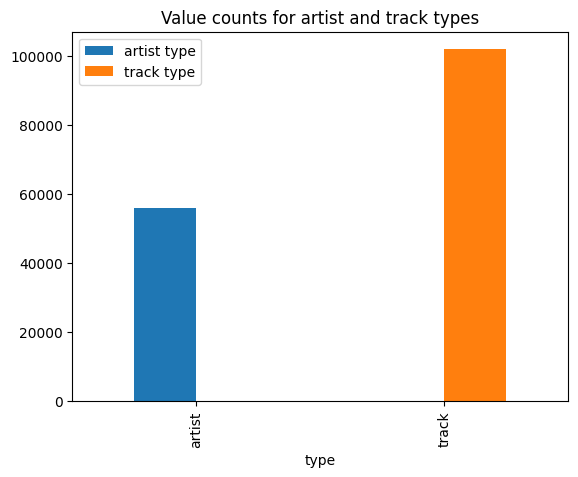

In [5]:
# show the count of variables in the type column
counts = pd.DataFrame({
    "artist type": data_artists["type"].value_counts(),
    "track type": data_tracks["type"].value_counts()
})

counts.plot.bar()
plt.title("Value counts for artist and track types")
plt.show()

> As it can be seen from the above count plot, the "type" column for both data_artists and data_tracks is repetitive.

In [6]:
empty_genres = data_artists["genres"].apply(lambda x: len(ast.literal_eval(x)) == 0)

print("Number of empty genre lists:", empty_genres.sum())
print("Percentage:", empty_genres.mean() * 100)

Number of empty genre lists: 23540
Percentage: 41.93910456270377


> In the artists dataframe, the first column that is called "unnamed" and the column "track_name_prev" can be removed since they are not needed. The column "type" is not needed since its only value is "artist". The "followers" column will not be needed, since we already have the "popularity" column that has numerical values from 1 to 100 calculated by the original authors of the paper to create a numerical measure of the artists' popularity. Finally, the column "genres" is decided to be not needed since it is overly detailed and has missing values.
> We only need the artist id, their popularity, and the corresponding track ids, so that we can relate the artist poularity to the tracks.

> In the tracks dataframe, the first column that is called "unnamed", and the columns "album_id", "analysis_url", "available_markets", "country", "disc_number", "href", "lyrics", "playlist", "preview_url", "speechiness", "time_signature", "track_href", "track_name_prev", "track_number", "uri", "track_name_prev", "type" can be removed since they are not needed.

Key: As previously mentioned, this is the estimated overall key of the track
. It uses standard Pitch Class notation (e.g., 0 = C, 1 = C♯/D♭, 2 = D). If no key is detected, the value is -1
Speechiness: This feature detects the presence of spoken words in a track
. The more the recording resembles speech (such as a talk show, audio book, or poetry), the closer the value will be to 1.0
Time_signature: This is an estimated overall meter of a track
. It is a notational convention that specifies how many beats are in each bar (or measure)

In [7]:
# remove unnecesary features before merging
data_artists = data_artists.drop(columns=["Unnamed: 0", "followers", "genres", "track_name_prev", "type"], errors="ignore")

data_tracks = data_tracks.drop(columns=["Unnamed: 0", "album_id", "analysis_url", "available_markets", "country",
                                         "disc_number", "href", "lyrics", "playlist", "preview_url", "track_href", 
                                         "track_name_prev", "track_number", "uri", "track_name_prev", "type"], errors="ignore")

In [8]:
# display the first 5 rows of the tracks and artists dataframes
for name, df in {
    "artists": data_artists,
    "tracks": data_tracks,
}.items():
    print(f"\n{name.upper()}")
    display(df.head(5))


ARTISTS


,artist_popularity,id,name,track_id
0,44,4mGnpjhqgx4RUdsIJiURdo,Juliano Cezar,0wmDmAILuW9e2aRttkl4aC
1,22,1dLnVku4VQUOLswwDFvRc9,The Grenadines,4wqwj0gA8qPZKLl5WVqXml
2,26,6YVY310fjfUzKi8hiqR7iK,Gangway,1bFqWDbvHmZe2f4Nf9qaD8
3,31,2VElyouiCfoYPDJluzwJwK,FADES,3MFSUBAidPzRBbIS7BDj1S
4,21,4agVy03qW8juSysCTUOuDI,Jean-Pierre Guignon,2r3q57FhxdsCyYr0kuDq4b



TRACKS


,acousticness,artists_id,danceability,duration_ms,energy,id,instrumentalness,key,liveness,loudness,mode,name,popularity,speechiness,tempo,time_signature,valence
0,0.294,['3mxJuHRn2ZWD5OofvJtDZY'],0.698,235584.0,0.606,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.151,-7.447,0.0,Blood,28.0,0.0262,115.018,4.0,0.6220
1,0.863,['4xWMewm6CYMstu0sPgd9jJ'],0.719,656960.0,0.308,3VAX2MJdmdqARLSU5hPMpm,0.000000,6.0,0.253,-10.340,1.0,The Ugly Duckling,31.0,0.9220,115.075,3.0,0.5890
2,0.750,['3hYaK5FF3YAglCj5HZgBnP'],0.466,492840.0,0.931,1L3YAhsEMrGVvCgDXj2TYn,0.000000,4.0,0.938,-13.605,0.0,Jimmy Launches His Own Range Of Greetings Cards,31.0,0.9440,79.565,4.0,0.0850
3,0.763,['2KQsUB9DRBcJk17JWX1eXD'],0.719,316578.0,0.126,6aCe9zzoZmCojX7bbgKKtf,0.000000,3.0,0.113,-20.254,0.0,The Crime At Pickets Mill,14.0,0.9380,112.822,3.0,0.5330
4,0.770,['3hYaK5FF3YAglCj5HZgBnP'],0.460,558880.0,0.942,1Vo802A38tPFHmje1h91um,0.000000,7.0,0.917,-13.749,1.0,Setup + Punchline = Joke,32.0,0.9430,81.260,4.0,0.0906


> Before merging, the names of the columns "id" and "name" in the artists dataframe will be changed to be "artist_id" and "artist_name". 

> Also, in the tracks dataframe, the names of the columns "id", "popularity", and "name" will be changed to be "track_id", "track_popularity", and "track_name".

In [9]:
data_artists = data_artists.rename(columns={
    "id": "artist_id",
    "name": "artist_name"
    })

data_tracks = data_tracks.rename(columns={
    "id": "track_id",
    "name": "track_name",
    "popularity": "track_popularity"
})

##### Missing Value Analysis

In [10]:
for name, df in {
    "artists": data_artists,
    "tracks": data_tracks,
}.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    
    print(f"\nMissing values in {name.upper()}:")
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)


Missing values in ARTISTS:
artist_name    1
dtype: int64

Missing values in TRACKS:
No missing values.


##### Unique Value Analysis

In [11]:
print("\nUniqueness checks")

print("\ndata_artists['artist_id']:")
print("Unique values:", data_artists["artist_id"].nunique())
print("Total rows:", len(data_artists))
print("All unique?", data_artists["artist_id"].is_unique)

print("\ndata_tracks['artists_id']:")
print("Unique values:", data_tracks["artists_id"].nunique())
print("Total rows:", len(data_tracks))
print("All unique?", data_tracks["artists_id"].is_unique)

print("\ndata_tracks['track_id']:")
print("Unique values:", data_tracks["track_id"].nunique())
print("Total rows:", len(data_tracks))
print("All unique?", data_tracks["track_id"].is_unique)


Uniqueness checks

data_artists['artist_id']:
Unique values: 56129
Total rows: 56129
All unique? True

data_tracks['artists_id']:
Unique values: 54673
Total rows: 101939
All unique? False

data_tracks['track_id']:
Unique values: 101939
Total rows: 101939
All unique? True


In [12]:
# show the duplicated artists_id rows in data_tracks
data_tracks[data_tracks["artists_id"].duplicated(keep=False)].sort_values("artists_id")

,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence
63856,0.000147,['0027wHZDQXpRll4ckwDGad'],0.480,221387.0,0.804,6Ovi0f2Ant45moF9zJNERx,0.000049,11.0,0.1240,-4.437,0.0,Second Soul,38.0,0.0508,140.015,4.0,0.315
56945,0.000636,['0027wHZDQXpRll4ckwDGad'],0.479,223320.0,0.887,0NVymX3RQRwxeKd80LNXhp,0.000086,2.0,0.2600,-5.115,1.0,Second Soul - Lenno & Jesse Oliver Remix Singl...,20.0,0.0346,127.981,4.0,0.201
89082,0.287000,['002oyMRzxTzEsBRLzACi8d'],0.549,217067.0,0.848,2nWAYmsTPSpza7X5tY6ZrH,0.000004,8.0,0.0933,-4.245,1.0,Piste.,44.0,0.0346,127.375,4.0,0.373
81771,0.034000,['002oyMRzxTzEsBRLzACi8d'],0.524,235107.0,0.841,4WqsrF7TJMNcXpALt6amw6,0.000016,2.0,0.0912,-4.444,0.0,Aamun Kuiskaus,51.0,0.0346,126.224,4.0,0.404
1169,0.371000,['002oyMRzxTzEsBRLzACi8d'],0.380,291253.0,0.425,0e0FFeJLCNrqO1abELMG21,0.015700,5.0,0.1750,-6.298,1.0,Häävalssi,35.0,0.0299,79.637,4.0,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95663,0.366000,['7zrkALJ9ayRjzysp4QYoEg'],0.629,201182.0,0.686,1GNvthYF2Ml5iflBVWjld7,0.878000,5.0,0.2320,-8.826,0.0,Turnmills - Edit,27.0,0.0350,115.020,4.0,0.535
58207,0.211000,['7zsin6IgVsR1rqSRCNYDwq'],0.545,192627.0,0.508,1GlvVIPOzbZyHIDaFF8eIc,0.000000,7.0,0.0944,-7.012,1.0,Let Her Go,50.0,0.0297,145.981,4.0,0.310
76618,0.213000,['7zsin6IgVsR1rqSRCNYDwq'],0.341,190280.0,0.539,6GRDI9suQHikFP6euIXnpq,0.000064,5.0,0.1090,-5.760,1.0,Hero,66.0,0.0265,174.564,4.0,0.267
87791,0.121000,['7zsin6IgVsR1rqSRCNYDwq'],0.642,210813.0,0.558,1dlsI0d27dT8R7XK9pTY8X,0.000005,8.0,0.0896,-9.661,1.0,Girl Who Washed Ashore,39.0,0.0288,78.017,4.0,0.803


> This shows that there are multiple tracks for some artists in the database, which is expected.

##### Tracks with Multiple Artists (ft.)

In [13]:
# show the duplicated artists_id rows in data_tracks
multi_artist_rows = data_tracks[
    data_tracks["artists_id"].apply(lambda x: len(ast.literal_eval(x)) > 1)
]

multi_artist_rows.head()

,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence
8,0.7520,"['5uNTrZ1JlKsnpTeFyKWPYO', '3pZ60MK5NPuXtBVJx1...",0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.1440,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.483
10,0.1010,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...",0.748,237667.0,0.666,01zME4q62SDPtD0hOSmTrG,0.000653,6.0,0.0976,-6.094,0.0,Creature Kind,47.0,0.0833,114.982,4.0,0.359
59,0.1480,"['7Czvx73uua4PB239Dza1Je', '2weGfox1CWg9HmmwDg...",0.790,174189.0,0.722,2kmakreNNd0A2UAPA1hIO3,0.000000,1.0,0.1720,-4.149,0.0,Soltera,49.0,0.0678,98.109,4.0,0.948
64,0.2880,"['1lNVs3gqrX6Qw01FqnP12N', '08HE59FnzdSLSYWues...",0.676,229956.0,0.719,6SO4EIIj2GPGPaX5KeWhoH,0.000000,1.0,0.1360,-4.847,1.0,Alma Gêmea,43.0,0.1240,107.064,4.0,0.769
76,0.0989,"['1NpKmfDYMhw1KJIIUCsX4O', '0Swkha61RB6f6xVAwy...",0.749,191592.0,0.479,3FaeRwOahQ8DyY1fSg6HO1,0.003200,0.0,0.3760,-4.789,1.0,Stay A Little Longer,46.0,0.1040,119.956,4.0,0.264


> Before merging, data_tracks rows with multiple artist_id should be handled. 

> It is decided that among the multiple artists, the one with the highest artist_popularity to be selected as to represent the strongest contributing artist influence.

In [14]:
# create a dictionary to look up the popularity of artists
artist_pop_lookup = data_artists.set_index("artist_id")["artist_popularity"].to_dict()

def get_popular_artist_id(artists_cell):
    artists_list = ast.literal_eval(artists_cell)
    
    # select artist with highest popularity
    best_artist = max(
        artists_list,
        key=lambda artist_id: artist_pop_lookup.get(artist_id, -1)
    )
    
    return best_artist  # return as string

# create new column
data_tracks["artist_id"] = data_tracks["artists_id"].apply(get_popular_artist_id)

In [15]:
multi_artist_rows = data_tracks[
    data_tracks["artists_id"].apply(lambda x: len(ast.literal_eval(x)) > 1)
]

multi_artist_rows.head()


,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence,artist_id
8,0.7520,"['5uNTrZ1JlKsnpTeFyKWPYO', '3pZ60MK5NPuXtBVJx1...",0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.1440,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.483,3pZ60MK5NPuXtBVJx1OkbN
10,0.1010,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...",0.748,237667.0,0.666,01zME4q62SDPtD0hOSmTrG,0.000653,6.0,0.0976,-6.094,0.0,Creature Kind,47.0,0.0833,114.982,4.0,0.359,5r5Va4lVQ1zjEfbJSrmCsS
59,0.1480,"['7Czvx73uua4PB239Dza1Je', '2weGfox1CWg9HmmwDg...",0.790,174189.0,0.722,2kmakreNNd0A2UAPA1hIO3,0.000000,1.0,0.1720,-4.149,0.0,Soltera,49.0,0.0678,98.109,4.0,0.948,7Czvx73uua4PB239Dza1Je
64,0.2880,"['1lNVs3gqrX6Qw01FqnP12N', '08HE59FnzdSLSYWues...",0.676,229956.0,0.719,6SO4EIIj2GPGPaX5KeWhoH,0.000000,1.0,0.1360,-4.847,1.0,Alma Gêmea,43.0,0.1240,107.064,4.0,0.769,08HE59FnzdSLSYWuesN8hm
76,0.0989,"['1NpKmfDYMhw1KJIIUCsX4O', '0Swkha61RB6f6xVAwy...",0.749,191592.0,0.479,3FaeRwOahQ8DyY1fSg6HO1,0.003200,0.0,0.3760,-4.789,1.0,Stay A Little Longer,46.0,0.1040,119.956,4.0,0.264,1NpKmfDYMhw1KJIIUCsX4O


In [16]:
# delete the temporary dataframe
del multi_artist_rows

In [17]:
# remove the artists_id column
data_tracks = data_tracks.drop(columns=["artists_id"], errors="ignore")

##### Merging

In [18]:
artist_name_lookup = data_artists.set_index("artist_id")["artist_name"]

# insert artist_popularity into data_tracks based on artist_id
data_tracks["artist_popularity"] = data_tracks["artist_id"].map(artist_pop_lookup)

# insert artist_name into data_tracks based on artist_id
data_tracks["artist_name"] = data_tracks["artist_id"].map(artist_name_lookup)

data_tracks.head(10)

,acousticness,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence,artist_id,artist_popularity,artist_name
0,0.294,0.698,235584.0,0.606,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.151,-7.447,0.0,Blood,28.0,0.0262,115.018,4.0,0.6220,3mxJuHRn2ZWD5OofvJtDZY,28,Jesse Markin
1,0.863,0.719,656960.0,0.308,3VAX2MJdmdqARLSU5hPMpm,0.000000,6.0,0.253,-10.340,1.0,The Ugly Duckling,31.0,0.9220,115.075,3.0,0.5890,4xWMewm6CYMstu0sPgd9jJ,36,Favorite Kids Stories
2,0.750,0.466,492840.0,0.931,1L3YAhsEMrGVvCgDXj2TYn,0.000000,4.0,0.938,-13.605,0.0,Jimmy Launches His Own Range Of Greetings Cards,31.0,0.9440,79.565,4.0,0.0850,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
3,0.763,0.719,316578.0,0.126,6aCe9zzoZmCojX7bbgKKtf,0.000000,3.0,0.113,-20.254,0.0,The Crime At Pickets Mill,14.0,0.9380,112.822,3.0,0.5330,2KQsUB9DRBcJk17JWX1eXD,10,Ambrose Bierce
4,0.770,0.460,558880.0,0.942,1Vo802A38tPFHmje1h91um,0.000000,7.0,0.917,-13.749,1.0,Setup + Punchline = Joke,32.0,0.9430,81.260,4.0,0.0906,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
5,0.971,0.367,183653.0,0.349,4PrAZpH9Ic7S47E78BN6E4,0.296000,11.0,0.633,-7.740,1.0,Already Gone,45.0,0.0268,81.850,4.0,0.1920,3kzwYV3OCB010YfXMF0Avt,62,Alvvays
6,0.824,0.688,29240.0,0.304,1WJzRtI1ABzV3TPIeJZVvi,0.000000,10.0,0.142,-9.960,1.0,Three Blind Mice,0.0,0.5310,77.056,3.0,0.4140,4xWMewm6CYMstu0sPgd9jJ,36,Favorite Kids Stories
7,0.719,0.513,591160.0,0.889,6ileHaSaGI8UjUK1jQu6jm,0.000000,3.0,0.722,-13.470,0.0,They Made It So Easy,26.0,0.9340,89.024,4.0,0.2280,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
8,0.752,0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.144,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.4830,3pZ60MK5NPuXtBVJx1OkbN,37,Ralph Fiennes
9,0.690,0.529,573280.0,0.900,00upOxUCEPl1CMr1axg52f,0.000000,5.0,0.971,-13.482,0.0,"Applying For A Job, The Jimmy Carr Way",29.0,0.9380,86.335,4.0,0.2140,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr


In [19]:
# example table (use your own DataFrame)
df = data_tracks[["duration_ms", "track_name", "speechiness", "artist_name"]].head(5)

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 loc='center')

# improve readability
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(df.columns))))

# save image
plt.savefig("../reports/figures/table.png", dpi=300, bbox_inches='tight')
plt.close()

In [20]:
# check if there are any missing values in the artist_popularity column
# due to a possible mismatch in the artist_id columns in both data_tracks and data_artists
print(f"Number of missing artist popularity values: {data_tracks["artist_popularity"].isna().sum()}")

Number of missing artist popularity values: 0


##### Cleaning

> The table above shows the first 10 rows of the merged data. One of the artists is Jimmy Carr. And the some of the corresponding tracks are "Jimmy Launches His Own Range Of Greetings Cards", "They Made It So Easy", and "Applying For A Job, The Jimmy Carr Way". These are stand-up clips and not songs. Similarly, there are other non-song tracks such as spoken-word recordings, audiobooks, or podcasts in data_tracks. There are a couple of ways to eliminate the non-songs.

In [21]:
features = [
    "duration_ms",
    "liveness",
    "instrumentalness",
    "speechiness",
     "energy",
     "danceability",
     "valence"
]

data_tracks[features].describe()

,duration_ms,liveness,instrumentalness,speechiness,energy,danceability,valence
count,1.019390e+05,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000
mean,2.467708e+05,0.197640,0.148776,0.128841,0.586479,0.586015,0.482813
std,1.904303e+05,0.175391,0.304024,0.203324,0.260170,0.177724,0.261690
min,1.155000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.840000e+05,0.095600,0.000000,0.036400,0.411000,0.480000,0.271000
50%,2.168930e+05,0.124000,0.000037,0.050600,0.629000,0.610000,0.477000
75%,2.610550e+05,0.241000,0.034400,0.104000,0.798000,0.714000,0.693000
max,5.505831e+06,0.999000,1.000000,0.969000,1.000000,0.989000,0.993000


In [22]:
data_tracks[features].skew(numeric_only=True)

duration_ms         9.743927
liveness            2.258462
instrumentalness    1.817007
speechiness         3.014812
energy             -0.503321
danceability       -0.625430
valence             0.061098
dtype: float64

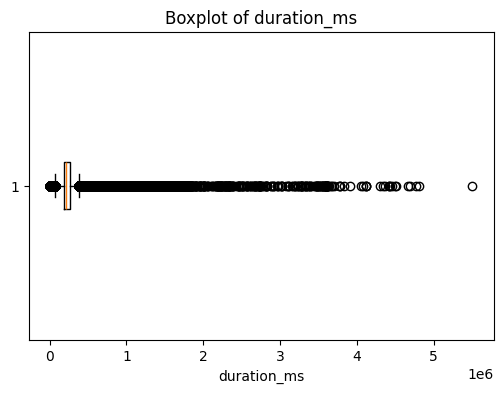

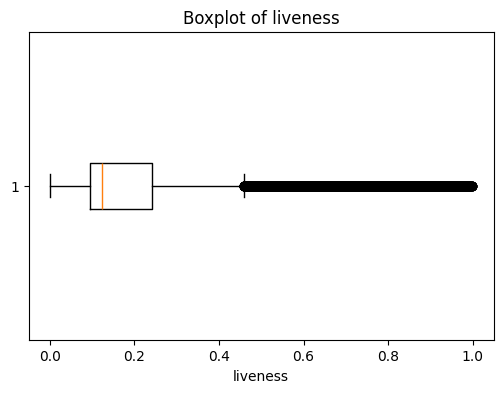

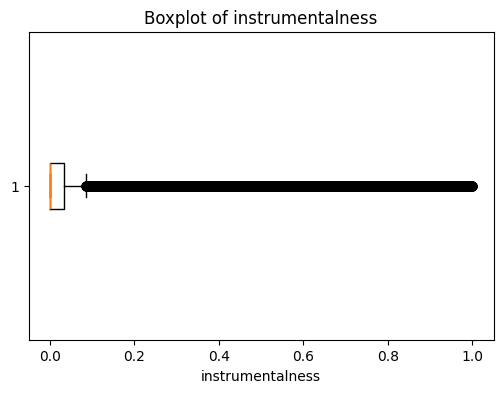

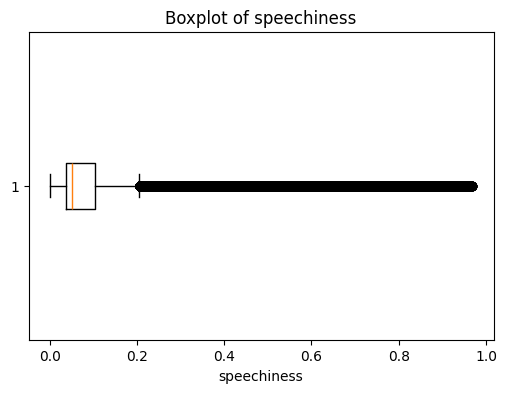

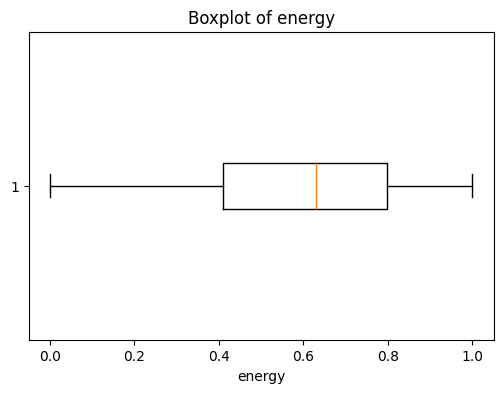

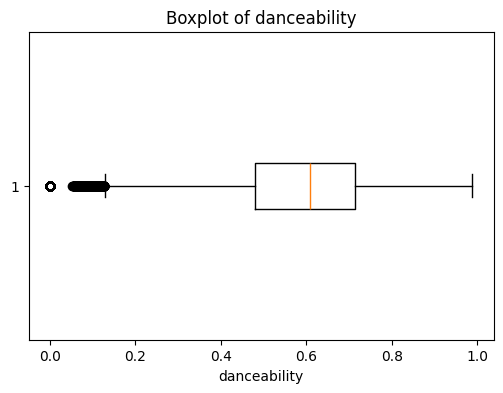

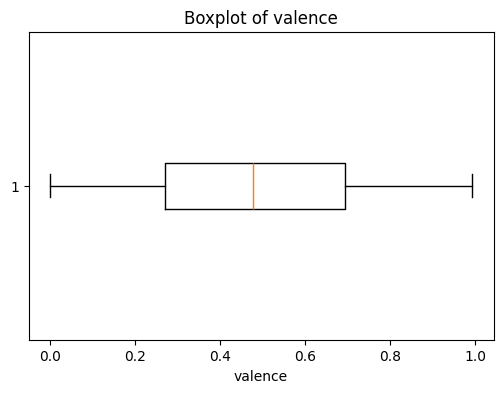

In [23]:
for feature in features:
    plt.figure(figsize=(6,4))
    plt.boxplot(data_tracks[feature], vert=False)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

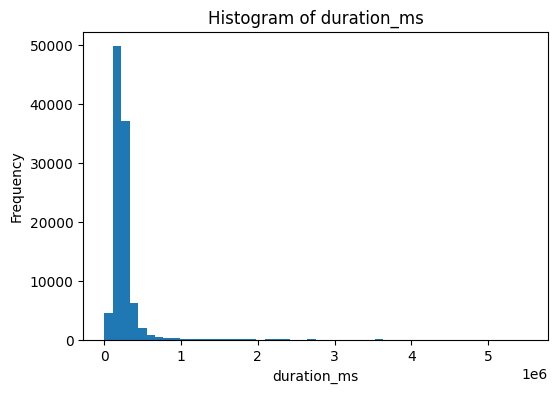

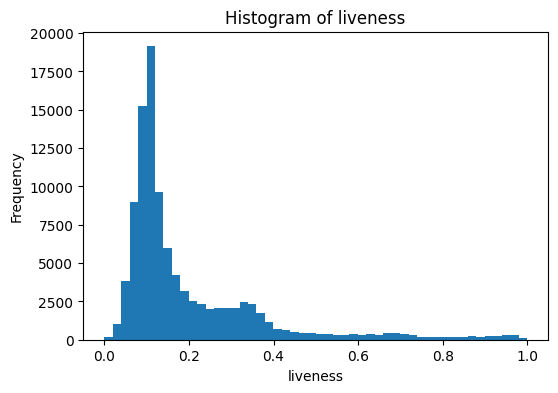

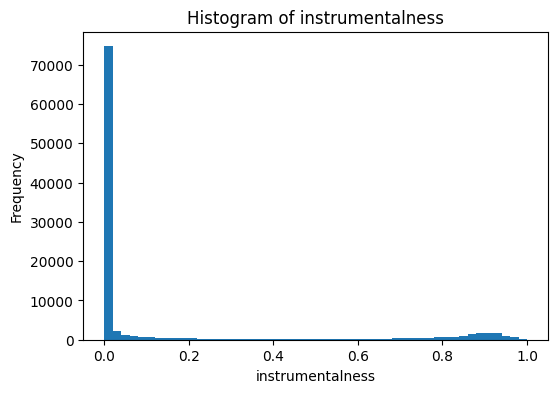

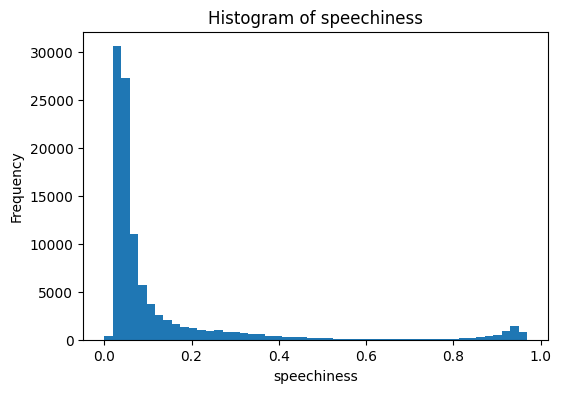

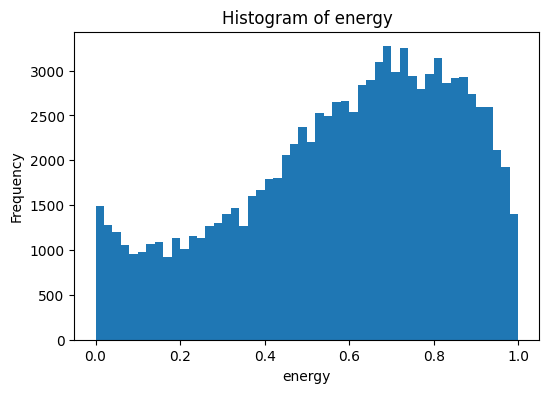

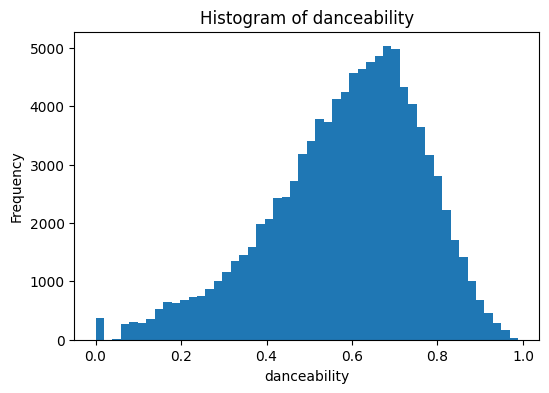

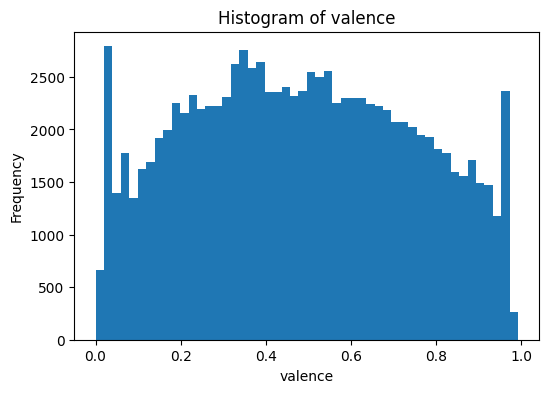

In [24]:
for feature in features:
    plt.figure(figsize=(6,4))
    plt.hist(data_tracks[feature], bins=50)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [25]:
features_high = ["duration_ms", "liveness", "speechiness"]
features_low = ["duration_ms", "speechiness", "instrumentalness", "energy", "danceability", "valence"]

# check highest values
for feature in features_high:
    print(f"\nTop values for {feature.upper()}:")
    display(
        data_tracks.sort_values(feature, ascending=False)[
            ["track_name", "artist_name", feature]
        ].head(10)
    )

# (optional) check lowest values for others
for feature in features_low:
    print(f"\nLowest values for {feature.upper()}:")
    display(
        data_tracks.sort_values(feature, ascending=True)[
            ["track_name", "artist_name", feature]
        ].head(10)
    )


Top values for DURATION_MS:


,track_name,artist_name,duration_ms
48041,A Guide to Men - Helen Rowland,DBS Audiobooks,5505831.0
76678,Introductory Lecture to Buddhism,Dalai Lama,4811520.0
95353,Stadium Hotel,King Dr. Saheed Osupa,4770973.0
36904,Thanksgiving,King Wasiu Ayinde,4694040.0
44351,The Letters & Journals Of Lord Nelson - Part 1,Charles Dance,4667397.0
7190,The Adventure of the Speckled Band,Sir Arthur Conan Doyle,4508318.0
51104,"Thunderstorm, Rain, Ocean Waves - Relaxing Sou...",Healing Sounds for Deep Sleep and Relaxation,4500037.0
7194,The Adventure of the Copper Beeches,Sir Arthur Conan Doyle,4462995.0
8370,The Adventure of the Beryl Coronet,Sir Arthur Conan Doyle,4437892.0
26806,Rag Lalit,Ram Narayan,4423000.0



Top values for LIVENESS:


,track_name,artist_name,liveness
64247,Et toute la ville en parle - En public,Michèle Torr,0.999
65606,Is This Love - Ao Vivo,Natiruts,0.999
43617,Jesús (feat. Marcos Witt),Marcos Witt,0.998
43008,Medley: E Ba Dupe F'oluwa / Sunny Loni Ariya -...,King Sunny Ade,0.998
69497,El Próximo Viernes - Live Version,Thalía,0.997
36815,Eres Suficiente,Danilo Montero,0.997
70551,Come Taste and See (Live),Red Rocks Worship,0.996
95412,Long Train Runnin' - Live,The Doobie Brothers,0.995
20493,Mueve Mueve,Juan Antonio Labra,0.994
42444,Lanterna dos Afogados,Maria Gadú,0.993



Top values for SPEECHINESS:


...

,track_name,artist_name,energy
60390,Pink Brown White Noise,Peninsulas,0.0
35006,Appliance With WN,University Of WN,0.0
46925,Tone Pan,BBVB,0.0
20477,Marchin' On,The Smashing Pumpkins,0.0
45894,White Noise: Turbines,Outside Broadcast Recordings,0.0
45887,Digistorm,René Watz,0.0
45854,L-R Noise,Lübecker,0.0
52186,Higher Freq Noise,Wavelength Minds,0.0
29806,Ground Support Electric Noise,Love Noise,0.0
52178,Dulled Noise Binaural,BBVB,0.0



Lowest values for DANCEABILITY:


,track_name,artist_name,danceability
13347,Sista varvet,Various Artists,0.0
39993,Introspective,Ogden Nash,0.0
3846,Legit Boss,Sasha Banks,0.0
37308,Bra jobbat!,Various Artists,0.0
22554,Feel The Glow,Naomi,0.0
37989,Varv tre,Various Artists,0.0
29330,Mixed Noises .wav,Noise Factory,0.0
18377,What Do You Call That? Would You Repeat That P...,Travelanguage,0.0
29326,Machine Repeating,Empty Fields,0.0
16107,Esto es Charles Ans,Various Artists,0.0



Lowest values for VALENCE:


,track_name,artist_name,valence
45877,Binaural Noise,University Of WN,0.0
90399,Reklame,Anders Matthesen,0.0
45863,Radio Frequency,Latium,0.0
30175,Transportation Please Call A Taxi,Travelanguage,0.0
30180,Please Drive Slower I Am In A Hurry,Travelanguage,0.0
30184,I Would Like This Pressed,Travelanguage,0.0
36001,Breanna Stewart - My Playlist,Various Artists,0.0
72924,Efterlysning,Anders Matthesen,0.0
30200,Yes No,Travelanguage,0.0
30204,Bread Butter,Travelanguage,0.0


In [26]:
for col in ["duration_ms", "speechiness"]:
    print(f"\n{col} percentiles:")
    print(data_tracks[col].quantile([0.90, 0.95, 0.99]))


duration_ms percentiles:
0.90    335635.8
0.95    420977.7
0.99    948365.2
Name: duration_ms, dtype: float64

speechiness percentiles:
0.90    0.302
0.95    0.730
0.99    0.947
Name: speechiness, dtype: float64


Most songs are approximately below 7 minutes. Most songs have speechines about 0.73. Liveness is decided to not be used as a filtering feature.

In [27]:
for col in ["duration_ms", "instrumentalness", "energy"]:
    print(f"\n{col} percentiles:")
    print(data_tracks[col].quantile([0.01, 0.05, 0.10]))


duration_ms percentiles:
0.01     57889.9
0.05    116467.9
0.10    150011.8
Name: duration_ms, dtype: float64

instrumentalness percentiles:
0.01    0.0
0.05    0.0
0.10    0.0
Name: instrumentalness, dtype: float64

energy percentiles:
0.01    0.012838
0.05    0.081900
0.10    0.183000
Name: energy, dtype: float64


Most songs are longer than 1 minute. At least 10% of the tracks have exactly 0 instrumentalness. Most tracks have energy higher than 0.08.

In [28]:
mask = (
    (data_tracks["energy"] == 0) &
    (data_tracks["instrumentalness"] == 0) &
    (data_tracks["speechiness"] == 0)
)

print(mask.sum())
print(mask.sum() / len(data_tracks))

31
0.00030410343440685116


> A small subset of tracks exhibited zero values across multiple audio features (energy, instrumentalness, and speechiness), which is inconsistent with typical musical recordings. These entries were treated as anomalous and removed from the dataset.

In [29]:
# to clear out the podcasts and short non-musical recordings
data_tracks = data_tracks[
    (data_tracks["duration_ms"] > 60000) &
    (data_tracks["duration_ms"] < 600000) &
    (data_tracks["speechiness"] < 0.7)
]

# to clear out white noise
data_tracks_clean = data_tracks[
    ~(
        (data_tracks["energy"] == 0) &
        (data_tracks["instrumentalness"] == 0) &
        (data_tracks["speechiness"] == 0)
    )
]

#### Data Profiling (Step 3)

In [30]:
data_tracks.info()

<class 'pandas.DataFrame'>
Index: 94928 entries, 0 to 101938
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   acousticness       94928 non-null  float64
 1   danceability       94928 non-null  float64
 2   duration_ms        94928 non-null  float64
 3   energy             94928 non-null  float64
 4   track_id           94928 non-null  str    
 5   instrumentalness   94928 non-null  float64
 6   key                94928 non-null  float64
 7   liveness           94928 non-null  float64
 8   loudness           94928 non-null  float64
 9   mode               94928 non-null  float64
 10  track_name         94928 non-null  str    
 11  track_popularity   94928 non-null  float64
 12  speechiness        94928 non-null  float64
 13  tempo              94928 non-null  float64
 14  time_signature     94928 non-null  float64
 15  valence            94928 non-null  float64
 16  artist_id          94928 non-null  st

In [31]:
data_tracks.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,track_popularity,speechiness,tempo,time_signature,valence,artist_popularity
count,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000,94928.00000,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000,94928.000000
mean,0.328753,0.586643,229842.057075,0.603565,0.152852,5.269857,0.188465,-8.885022,0.61533,41.448529,0.085886,119.649284,3.903980,0.487749,49.423142
std,0.328315,0.177155,73008.256213,0.251706,0.306930,3.572577,0.164473,5.749035,0.48652,15.694686,0.093589,29.396838,0.435596,0.262831,19.571715
min,0.000000,0.000000,60013.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.034200,0.477000,186133.000000,0.443000,0.000000,2.000000,0.094400,-10.357000,0.00000,31.000000,0.035800,97.339750,4.000000,0.273000,36.000000
50%,0.204000,0.607000,216940.500000,0.645000,0.000060,5.000000,0.121000,-7.327000,1.00000,42.000000,0.048500,119.935000,4.000000,0.483000,51.000000
75%,0.589000,0.718000,257467.000000,0.805000,0.044325,8.000000,0.225000,-5.380000,1.00000,52.000000,0.087100,137.169500,4.000000,0.702000,64.000000
max,0.996000,0.989000,599786.000000,1.000000,1.000000,11.000000,0.999000,2.719000,1.00000,97.000000,0.699000,244.035000,5.000000,0.993000,100.000000


In [32]:
data_tracks.skew(numeric_only=True)

acousticness         0.718561
danceability        -0.538509
duration_ms          1.433813
energy              -0.579658
instrumentalness     1.775780
key                  0.000121
liveness             2.405144
loudness            -2.411113
mode                -0.474110
track_popularity    -0.068231
speechiness          2.826618
tempo                0.326643
time_signature      -4.122328
valence              0.051978
artist_popularity   -0.178705
dtype: float64

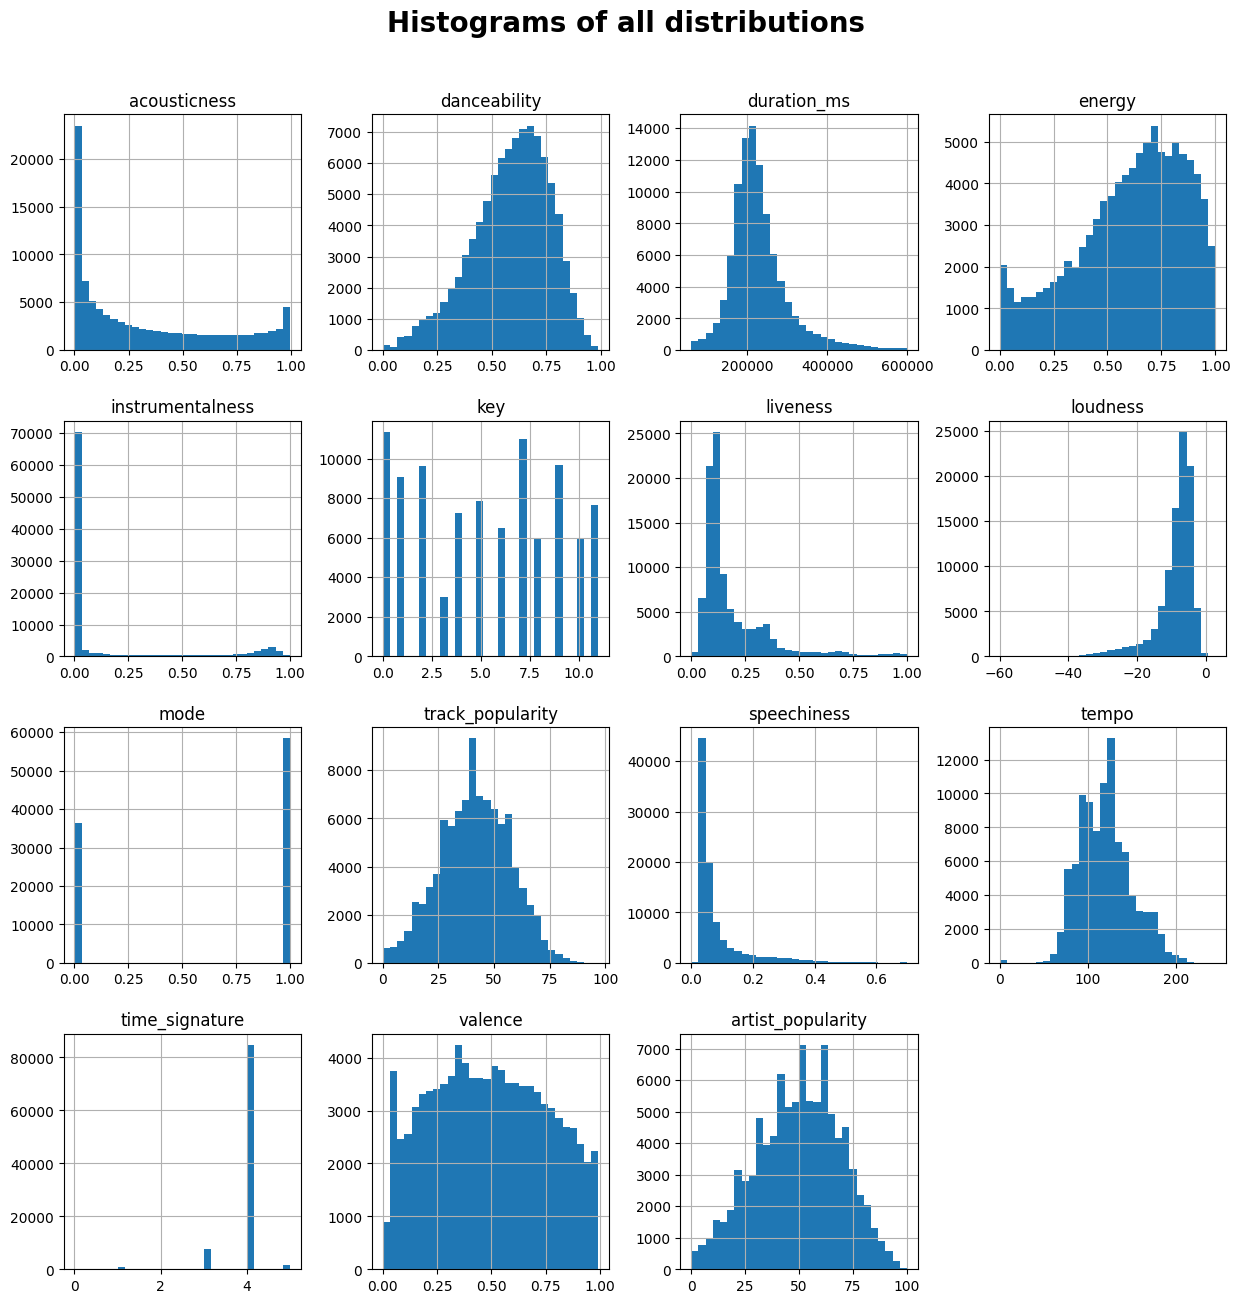

<Figure size 640x480 with 0 Axes>

In [33]:
data_tracks.drop(columns=["track_id", "track_name", "artist_id", "artist_name"]).hist(figsize=(15,15), bins=30)
plt.suptitle('Histograms of all distributions', y=0.95, fontsize=20, fontweight='semibold')

plt.show()
plt.subplots_adjust(hspace=0.5)

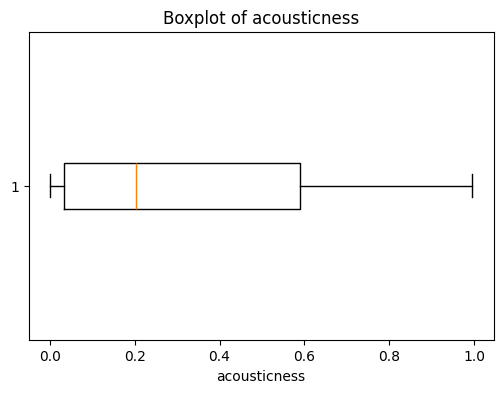

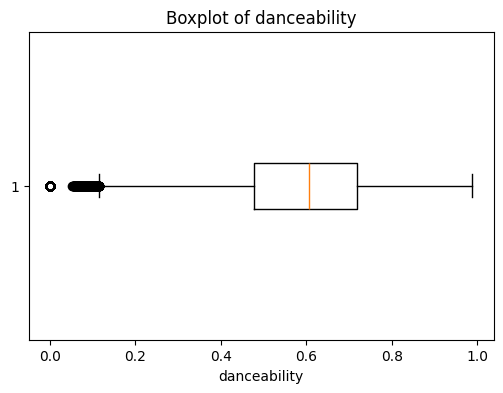

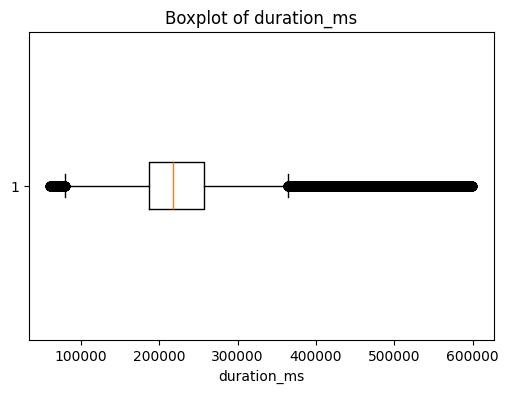

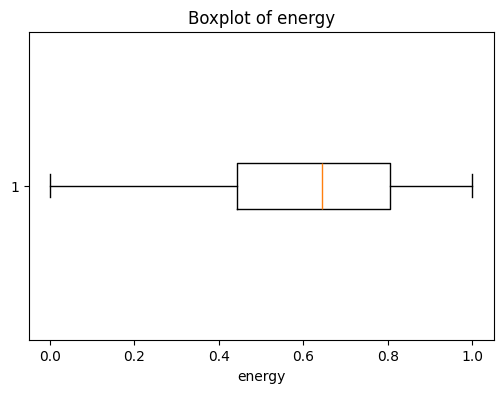

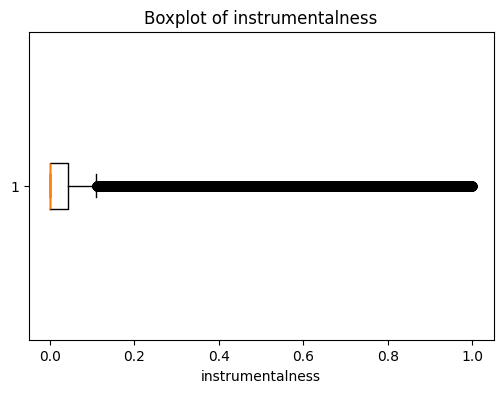

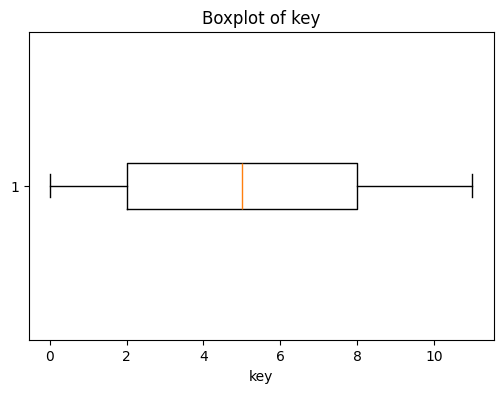

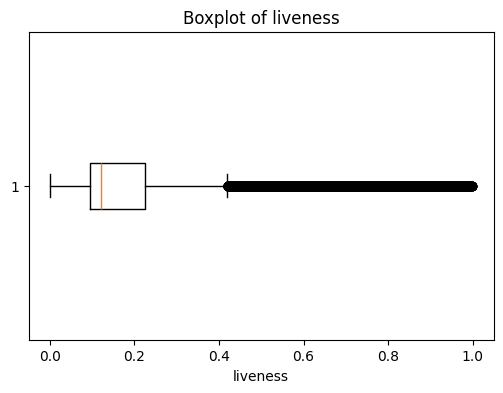

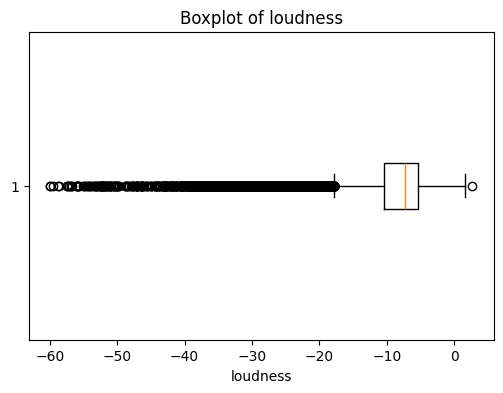

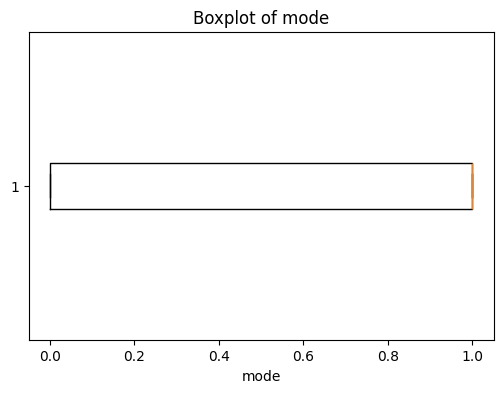

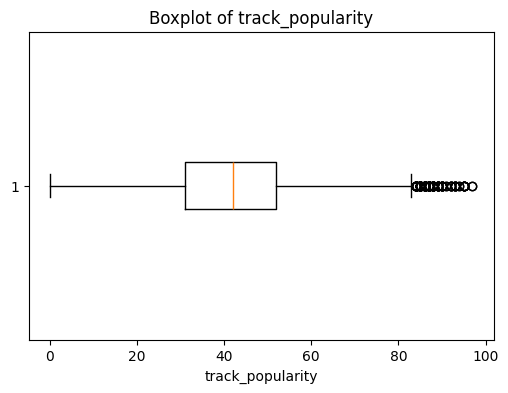

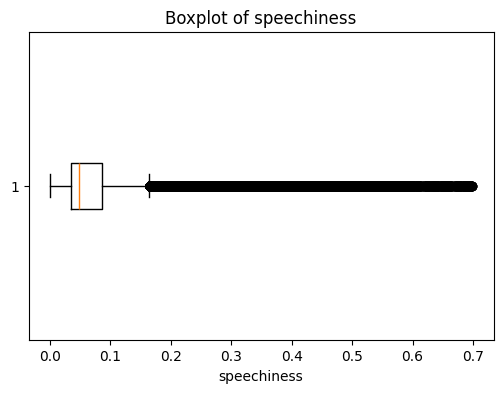

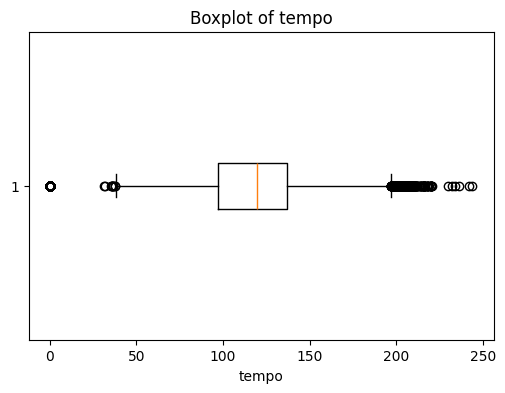

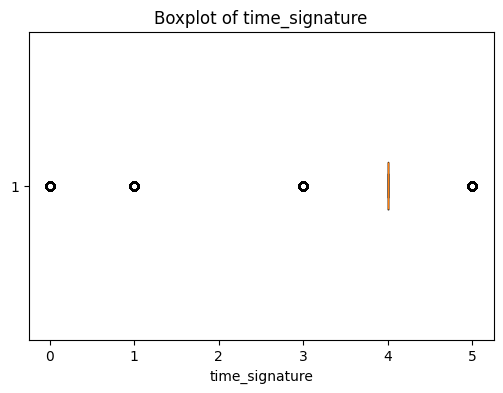

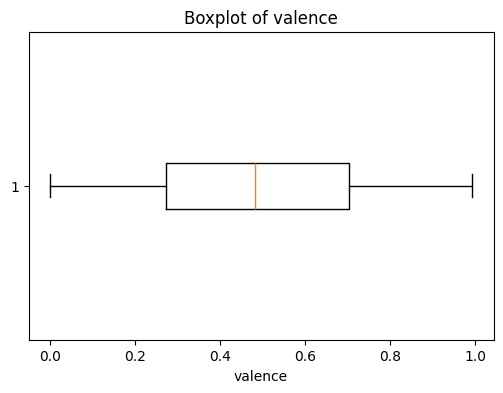

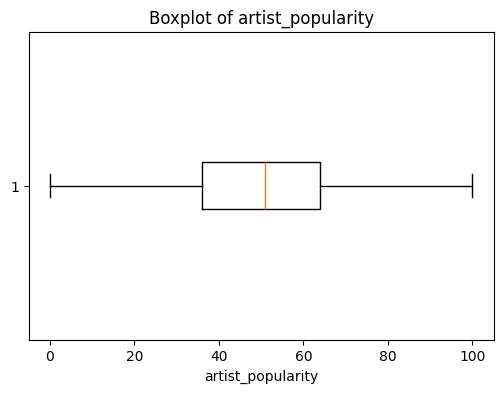

In [34]:
all_features = ["acousticness","danceability","duration_ms","energy","instrumentalness","key","liveness","loudness","mode","track_popularity","speechiness","tempo","time_signature","valence","artist_popularity"]

for feature in all_features:
    plt.figure(figsize=(6,4))
    plt.boxplot(data_tracks[feature], vert=False)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

**Key is the estimated overall key of the track**
- It uses standard Pitch Class notation, where integers correspond to specific pitches (e.g., 0 = C, 1 = C♯/D♭, 2 = D)
- If the system cannot detect a key, it assigns a value of -1

**Mode indicates the modality (major or minor) of a song, which determines the type of scale used for its melody.**
- In the dataset, Major is represented by 1 and Minor is represented by 0

**Time_signature is an estimated overall meter of a track**
- It is a convention that specifies how many beats are contained in each bar (or measure)

**Valence is a measure ranging from 0.0 to 1.0 that describes the musical positiveness conveyed by a song**
- Tracks with high valence sound more positive (e.g., happy, cheerful, or euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, or angry)

#### Naive Baseline (Step 4)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = data_tracks["track_popularity"]

# baseline prediction
mean_popularity = y_true.mean()
y_pred_baseline = np.full(len(y_true), mean_popularity)

# metrics
mae = mean_absolute_error(y_true, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
r2 = r2_score(y_true, y_pred_baseline)

print("Baseline Performance:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Baseline Performance:
MAE: 12.654
RMSE: 15.695
R²: 0.000


The performance of the regression models is evaluated using Mean Absolute Error (MAE) and the coefficient of determination (R²). MAE provides an interpretable measure of the average prediction error, while R² evaluates how well the model explains the variability in the target variable. These two metrics complement each other by capturing both prediction accuracy and explanatory power.

As a baseline, a naive model is constructed by predicting the mean track popularity for all observations. This baseline represents the best constant prediction in the absence of feature information. The baseline model yields an R² score close to zero, indicating that it does not explain any variability in the data. Therefore, any meaningful model should outperform this baseline in both MAE and R².